In [26]:
import darts
from darts.metrics import smape
from darts.models.forecasting.prophet_model import Prophet
from data_pipeline import ElectricityDataPipeline

import numpy as np

In [3]:
model = Prophet.load("/workspaces/darts/a-debug/prophet-test.pt")


In [6]:
x = model.predict(3000)

In [ ]:

data_pipeline = ElectricityDataPipeline(
        target_component="Value_NE5",
    )
data_pipeline.prepare_data()

❗❗Using subset_percentage < 1.0 (0.3) for development purposes. This will speed up the data loading and processing, but results may not be representative.❗❗


Working directory: /workspaces/darts
--- Starting Data Preparation ---
Loaded full dataset with components: ['Value_NE5', 'Value_NE7', 'Hr [%Hr]', 'RainDur [min]', 'StrGlo [W/m2]', 'T [°C]', 'WD [°]', 'WVs [m/s]', 'WVv [m/s]', 'p [hPa]']
Target series selected: 'Value_NE5'
Target series selected: 'Value_NE5'
Using 8 data-based covariates: ['Hr [%Hr]', 'RainDur [min]', 'T [°C]', 'WD [°]', 'WVv [m/s]', 'p [hPa]', 'WVs [m/s]', 'StrGlo [W/m2]']
Using 3 future covariates: ['holidays_custom', 'month', 'weekday']
Subsetted data to 80611 points (30%)
Splitting data at 2016-06-29 19:00:00 and 2016-11-02 17:45:00
Train size: 52397, Val size: 12091, Test size: 16123
--- Data Preparation Complete ---


In [84]:
model = Prophet(
        changepoint_prior_scale=0.01, 
        seasonality_prior_scale=0.1,
        seasonality_mode="additive",
        add_seasonalities={'name': 'monthly', 'seasonal_periods': 30.5 * 24, 'fourier_order': 5},
    )

prophet_hist = model.fit(
    data_pipeline.train_scaled,
    future_covariates=data_pipeline.future_covariates_scaled
    )

14:39:01 - cmdstanpy - INFO - Chain [1] start processing
14:39:10 - cmdstanpy - INFO - Chain [1] done processing


<Axes: xlabel='Timestamp'>

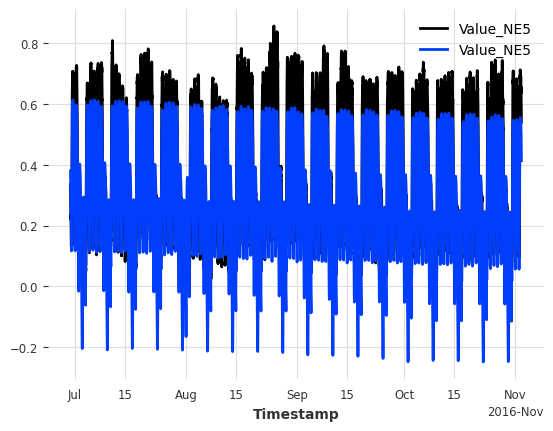

In [12]:
x = model.predict(len(data_pipeline.val_scaled))
data_pipeline.val_scaled.plot()
x.plot()

np.float64(35.402323891633166)

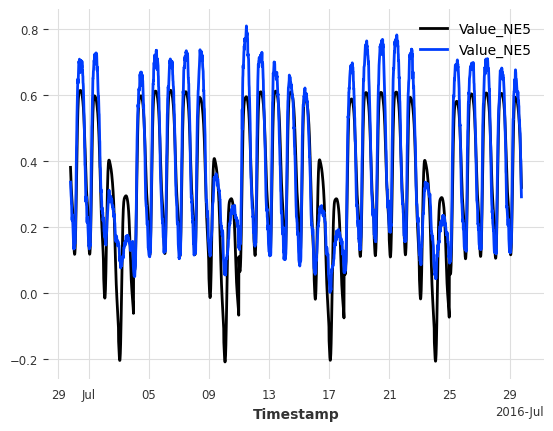

In [14]:
y = model.predict(2880)
y.plot()
yz = data_pipeline.val_scaled[:2880]
yz.plot()

smape(y, yz)

<Axes: xlabel='Timestamp'>

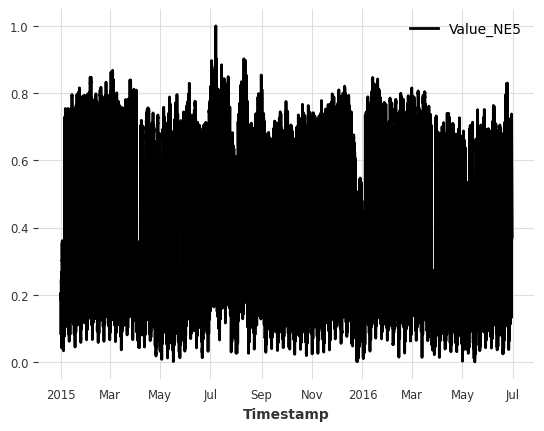

In [29]:
train_ts.plot()

<Axes: xlabel='Timestamp'>

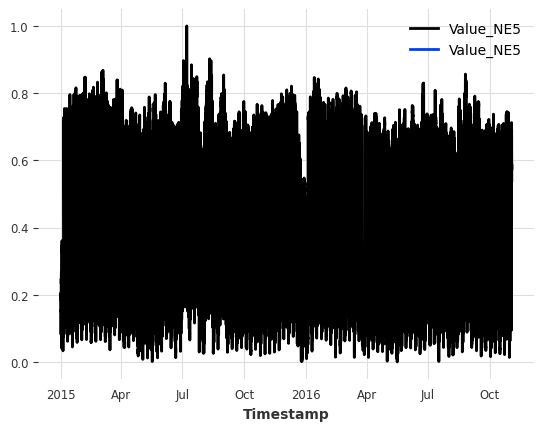

In [32]:
train_ts = data_pipeline.train_scaled
val_ts = data_pipeline.val_scaled
train_ts.append(val_ts).plot()
val_ts[:0].plot()

In [59]:
eval_timeframe = 30 * 24 * 4
n_evals = int(np.floor(len(data_pipeline.val_scaled) / eval_timeframe))

train_ts = data_pipeline.train_scaled
val_ts = data_pipeline.val_scaled

all_smapes = []

for iteration in range(n_evals):
    print(f"retraining iteration {iteration}/{n_evals}")
    retrain_ts = train_ts.append(val_ts[:iteration*eval_timeframe])
    model.fit(
        series=retrain_ts,
        future_covariates=data_pipeline.future_covariates_scaled
    )
    prediction = model.predict(eval_timeframe)

    all_smapes.append(smape(val_ts[:(1+iteration)*eval_timeframe], prediction))

retraining iteration 0/17


14:07:34 - cmdstanpy - INFO - Chain [1] start processing
14:07:42 - cmdstanpy - INFO - Chain [1] done processing


retraining iteration 1/17


14:07:44 - cmdstanpy - INFO - Chain [1] start processing
14:07:51 - cmdstanpy - INFO - Chain [1] done processing


retraining iteration 2/17


...

14:10:13 - cmdstanpy - INFO - Chain [1] start processing
14:10:23 - cmdstanpy - INFO - Chain [1] done processing


retraining iteration 15/17


14:10:25 - cmdstanpy - INFO - Chain [1] start processing
14:10:39 - cmdstanpy - INFO - Chain [1] done processing


retraining iteration 16/17


14:10:40 - cmdstanpy - INFO - Chain [1] start processing
14:10:53 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
accuracy_rate = 1 - (smape_score / 100)
ies = normalized_execution_time / accuracy_rate if accuracy_rate > 0 else float('inf')
rcs = accuracy_rate / normalized_execution_time if normalized_execution_time > 0 else 0

with open("./eval-log.csv", "a") as file:
    writer = csv.writer(file)
    writer.writerow([model.model_name, model._module_name, epochs_trained, normalized_execution_time, smape_score, ies, rcs])

In [94]:
smape_score = np.mean(all_smapes)
normalized_execution_time = 100

accuracy_rate = 1 - (smape_score / 100)
ies = normalized_execution_time / accuracy_rate if accuracy_rate > 0 else float('inf')
rcs = accuracy_rate / normalized_execution_time if normalized_execution_time > 0 else 0

In [97]:
accuracy_rate

np.float64(0.6452556900519163)

In [107]:
type(tmod).__name__

'TFTModel'

In [96]:
ies, rcs

(np.float64(154.97732378300168), np.float64(0.006452556900519163))

<Axes: xlabel='Timestamp'>

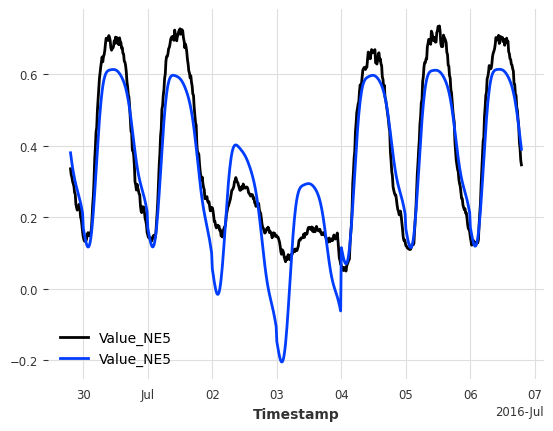

In [56]:
val_ts[:(1+iteration)*eval_timeframe].plot()
prediction.plot()

<Axes: xlabel='Timestamp'>

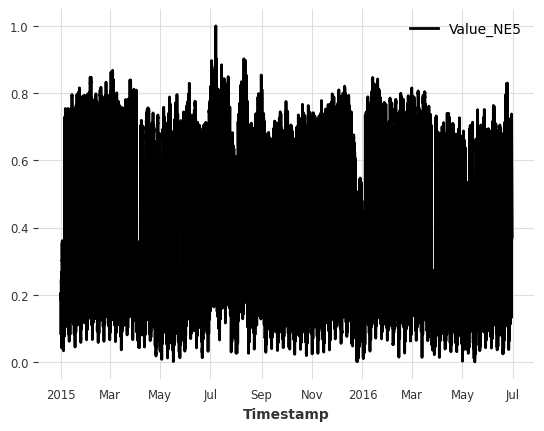

In [47]:
retrain_ts.plot()

In [ ]:
hist.epochs_trained

TFTModel(output_chunk_shift=0, hidden_size=16, lstm_layers=1, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=16, output_chunk_length=16, n_epochs=3)

In [90]:
from darts.models import TFTModel
import time

tmod = TFTModel(
    input_chunk_length=16, 
    output_chunk_length=16,
    n_epochs=100
    )

start_time = time.time()
hist = tmod.fit(
    series=data_pipeline.train_scaled[:500],
    future_covariates=data_pipeline.future_covariates_scaled,
    )
execution_time = time.time() - start_time
normalized_time = execution_time/hist.epochs_trained
print(execution_time, normalized_time, hist.epochs_trained)

Original TFT Model initialized... why?
Original _TFT_Module initialized... why?
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 2.4 K  | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 1.8 K  | train
6  | static_context_grn    

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


19.121238946914673 0.19121238946914673 100


In [93]:
tmod.model_name

'2025-07-09_14_46_20_torch_model_run_94894'